# Root finding

The roots (*aka zeros*) of a function are values of function arguments forwhich the function is zero:

Find $x$ such that:

$$ f(x) = 0 $$

It can become complicated when we consider vector $\vec{x}$ and even $\vec{f}$, but consider a special case of finding the roots of $\vec{f}(\vec{x})$ is our familiar linear system, $A \vec{x} -\vec{b} = \vec{0}$. Solving linear systems is a special case of root finding, which is generalized to nonlinear functions. 


## Roots of some nonlinear functions

Let's build some intuition by exploring some type of roots in 1D functions using the *graphical method*: Plot the function and examine where it crosses the x-axis.

NB: Note the structure of the code below - Since we don't know *a priori* where the roots will be, we have to take a series of initial guesses and cross our finger....  and even then we may fail to find them all!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

def plot_and_find_roots(func):
    x = np.linspace(-10, 10, 400)
    y = func(x)

    # Find roots
    x0s = np.arange(-10, 10, 1)
    roots = []
    for x0 in x0s:
        r = root(func, x0=x0)
        if r.success:
            roots.append((r.x[0], r.fun[0]))

    # Remove duplicate roots (within tolerance)
    unique_roots = []
    tol = 1e-6
    for rx, ry in roots:
        if not any(abs(rx - ux) < tol for ux, _ in unique_roots):
            unique_roots.append((rx, ry))

    # Plot with Matplotlib
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='f(x)')
    plt.axhline(0, color='black', linestyle='--', label='x-axis')
    if unique_roots:
        plt.scatter([rx for rx, _ in unique_roots], [0]*len(unique_roots), color='red', s=60, label='Roots')
    plt.title('Plot of f(x) and its Roots')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.legend()
    plt.grid(True)
    plt.show()

#### Example 1: Real roots - $x^2-4$

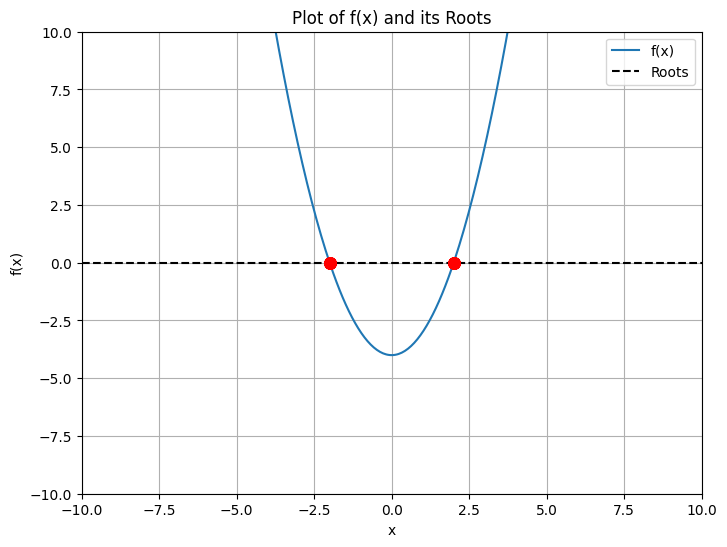

In [5]:
plot_and_find_roots(lambda x: x**2-4)

#### Example 2: No roots - $1/x$

C:\Users\wellandm\AppData\Local\Temp\ipykernel_18760\3010058334.py:1: RuntimeWarning: divide by zero encountered in divide
  plot_and_find_roots(lambda x: 1/x)


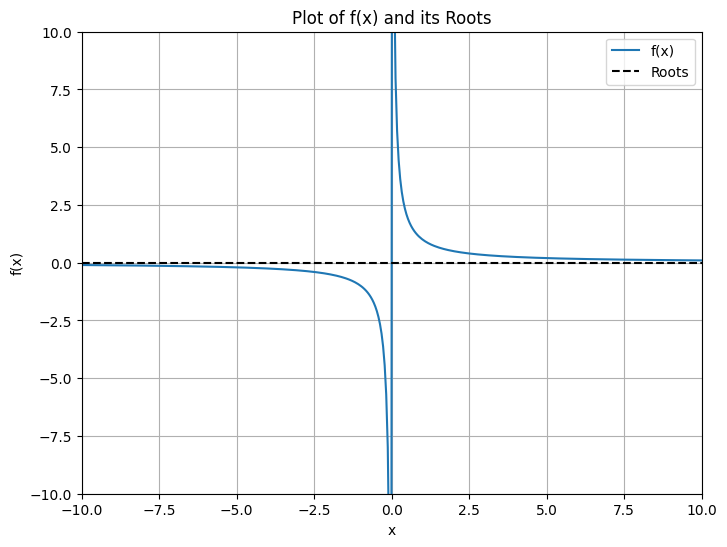

In [6]:
plot_and_find_roots(lambda x: 1/x)

(Noting that the vertical line is a plotting artifact).

#### Example 3: Infinite roots $sin(x^2)$

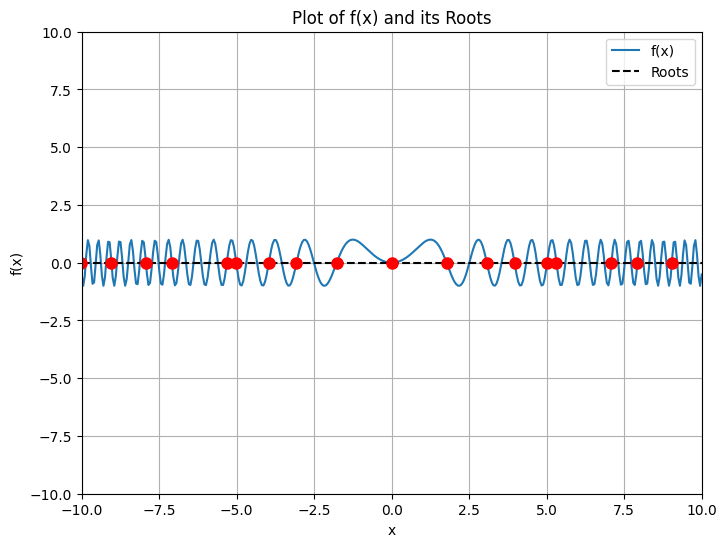

In [7]:
plot_and_find_roots(lambda x: np.sin(x**2))

Only the roots closest to the initial guesses are found!

## Complex roots - $x^2+1$

Even the graphical method is not completely reliable due to the existence of *complex roots*

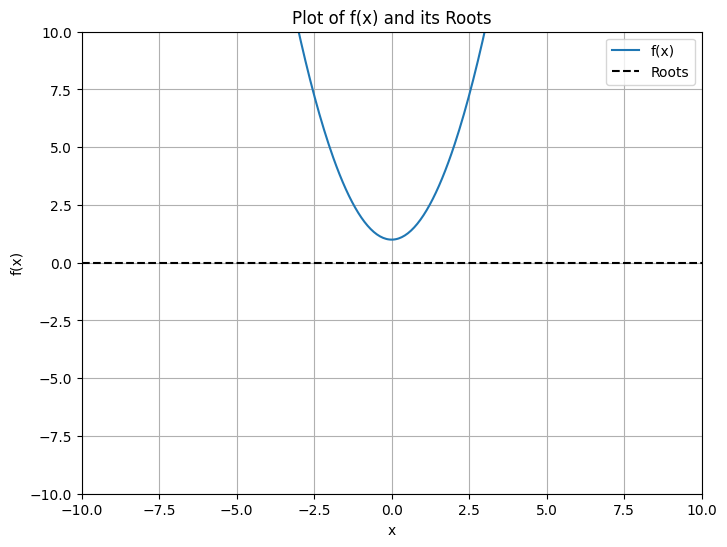

In [8]:
def fun(x):
    return x**2 + 1

# Wrong!
plot_and_find_roots(fun)

**But this is wrong!** The quadratic has 2 roots but we need to use a different method:

In [12]:
root(lambda x: x**2+1, x0 = [1+1j, 1-1j], method = "krylov")

 message: A solution was found at the specified tolerance.
 success: True
  status: 1
     fun: [1.67554859e-11-2.00209807e-11j 1.67554859e-11+2.00209807e-11j]
       x: [-1.00104904e-11+1.j -1.00104904e-11-1.j]
     nit: 6
  method: krylov
    nfev: 16

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

def complex_plot(func):
    real_range = np.linspace(-3, 3, 100)
    imag_range = np.linspace(-3, 3, 100)
    real_part = np.empty((len(real_range), len(imag_range)))

    for i, real in enumerate(real_range):
        for j, imag in enumerate(imag_range):
            z = complex(real, imag)
            result = func(z)
            real_part[i, j] = result.real

    # Find roots
    r = root(lambda x: x**2 + 1, x0=[1 + 1j, 1 - 1j], method="krylov")
    root_x = [root_val.real for root_val in r.x] if r.success else []
    root_y = [root_val.imag for root_val in r.x] if r.success else []

    # Plot with Matplotlib
    plt.figure(figsize=(7, 6))
    X, Y = np.meshgrid(real_range, imag_range, indexing='ij')
    cp = plt.contourf(X, Y, real_part, levels=50, cmap='viridis')
    plt.colorbar(cp, label='Real Part')
    if root_x:
        plt.scatter(root_x, root_y, color='red', s=60, label='Roots')
    plt.title('Complex Plot of f(z)')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.legend()
    plt.show()

# Use the function to plot x**2 + 1
complex_plot(lambda z: z**2 + 1)

In [ ]:
# 3D surface plot of the absolute value of f(z) over the complex plane
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def complex_surface_plot(func):
    real_range = np.linspace(-3, 3, 100)
    imag_range = np.linspace(-3, 3, 100)
    abs_val = np.empty((len(real_range), len(imag_range)))

    for i, real in enumerate(real_range):
        for j, imag in enumerate(imag_range):
            z = complex(real, imag)
            result = func(z)
            abs_val[i, j] = abs(result)

    X, Y = np.meshgrid(real_range, imag_range, indexing='ij')

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, abs_val, cmap='viridis')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='|f(z)|')
    ax.set_title('3D Surface Plot of |f(z)|')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_zlabel('|f(z)|')
    plt.show()

# Example: 3D surface plot for x**2 + 1
complex_surface_plot(lambda z: z**2 + 1)

DON'T WORRY - We won't be dealing with complex numbers in general in this course :-)

## Pathalogical / well-behaved functions

Some functions can be very tricky indeed, such as the Weierstrass Function,

$$ 
\sum_{n=0}^\infty a^n cos (b^n \pi x) \\
0<a<1 \\
a b > 1+\frac{3 \pi}{2}
$$

which looks like:

![Weierstrass Function](WeierstrassFunction.svg)



This is a classic example of a continuous but **nowhere differentiable** function! It is a fractal, and yet roots do exist and may be on interest. It is a classic example of a *pathalogical* function. 

Different appliations will have different criteria for *pathalogical* vs *well behaved* functions, and no general definition exists although there is seldom dissagreement amoung non-mathematicians about which is which. 

Generally, well behaved functions don't have sharp corners, singularities, discontinuities, etc.